**Authors**: Firas Abouzahr (Northwestern), Sara Sussman (Fermilab)

# A Brief Introduction to pyPalace
[pyPalace](https://pypalace.readthedocs.io/en/latest/) is an open-source Python toolkit for simulating and analyzing superconducting quantum devices with AWS Palace.

[SQDMetal](https://github.com/sqdlab/SQDMetal) and pyPalace are complementary tools in this workshop series: SQDMetal provides an integrated Metal-to-Palace workflow in the quantum-device-design track, while **pyPalace exposes Palace's native configuration directly in Python** — the `Problems`, `Model`, `Domains`, `Boundaries`, and `Solver` blocks you build map one-to-one to what Palace expects on disk. If you already know Palace's config format, you are not learning a second abstraction—you are assembling the same files, with less boilerplate.

This notebook follows [Example 01 (eigenmode + EPR)](https://github.com/FirasAbouzahr/pyPalace/tree/main/Examples/example_01_eigenmode_EPR) in the pyPalace repository.

### What pyPalace helps you do:
* **Build** Palace configuration files from Python (Config + builder helpers)
* **Run** electrostatic, magnetostatic, eigenmode, and driven (time- or frequency-domain) simulations locally (mpirun) or on HPC (Slurm)
* **Extract standard outputs** (capacitance matrices, eigenfrequencies, S-parameters, fields)
* **Analyze superconducting circuits** with quantum-oriented utilities such as Lumped Oscillator Modeling (LOM) and Energy Participation Ratio (EPR)

### Meshing and design workflows
pyPalace does not lock you into one design toolchain.
* **Quantum Metal → mesh (built-in path):** Example workflows show how to take a Quantum Metal planar layout and mesh it with pyPalace's built-in meshing utilities (Gmsh-based), including physical groups for terminals and materials that Palace needs.
* **Any other meshed design:** Palace accepts a wide range of mesh formats (e.g. Gmsh .msh, Nastran .bdf, and others). You can mesh in Gmsh, Cubit, COMSOL export, or any tool that produces a Palace-compatible mesh—then point `config['Model']['Mesh']` at that file and build boundaries from the mesh attribute table.
So the mesh source is flexible; pyPalace's job is to connect your mesh + Palace config + solver run + analysis in Python.

### Typical workflow
1. Obtain or generate a mesh (Quantum Metal + pyPalace meshing, or an external mesher)
2. Build a Palace config in Python (materials, terminals, solver settings)
3. Run Palace through Simulation
4. Extract Hamiltonian or circuit parameters with LOM, EPR, or related analysis tools

### pyPalace resources
* [GitHub Homepage](https://github.com/FirasAbouzahr/pyPalace)
* [Documentation](https://pypalace.readthedocs.io/en/latest/)
* [end-to-end Examples](https://github.com/FirasAbouzahr/pyPalace/tree/main/Examples)

### <u>Before we start</u>
The shared workshop environment includes Palace and `mpirun`. We use `pypalace.palace_env.get_palace_executable()` to locate the Palace binary automatically. You will also need Python 3.9+ (3.11+ in the shared Docker image).

### <u>Contributing to pyPalace</u>
pyPalace is a community-driven project with a small maintainer team. The goal is a design- and mesh-agnostic Python layer for automating electromagnetic workflows. Issues, PRs, and feedback are welcome on [GitHub](https://github.com/FirasAbouzahr/pyPalace). For collaboration, contact [Firas Abouzahr](mailto:firasabouzahr2030@u.northwestern.edu).


# Eigenmode simulations for superconducting circuits

## What are eigenmode simulations?

Eigenmode simulations solve the source-free electromagnetic wave equation:

$$\nabla \times (\nabla \times \mathbf{E}) - \epsilon_r(\frac{\omega}{c})^2\mathbf{E} = 0$$

Palace is an open-source Finite Element Method (FEM) solver that performs complex physics simulations on digitized objects. To do this, a process called meshing first divides the complex geometric model into a network of small, simple shapes called elements. Palace then solves the physics equations piece by piece across this network to calculate how the whole structure will behave. In this light, more accurately, Palace solves the *discretized* version of the source-free electromagnetic wave equation (see the [Palace documentation](https://awslabs.github.io/palace/stable/reference/#Eigenmode-calculations)).

## Why eigenmode simulations?
Eigenmode simulations determine the natural resonant frequencies and electromagnetic field distributions supported by a structure. In other words, they identify the standing-wave modes that can exist without an external drive.

For superconducting circuits, eigenmode simulations are used to extract resonant frequencies, mode shapes, and quality factors. The resulting electric and magnetic field distributions can then be used in Energy Participation Ratio (EPR) analysis, which quantifies how electromagnetic energy is distributed throughout the device. These participation ratios are subsequently used to extract Hamiltonian parameters such as qubit anharmonicity ($\alpha$) and the resonator dispersive shift ($\chi$).


# Eigenmode simulation and EPR analysis of transmon-resonator system

## Coupled transmon-resonator device

For this workshop, we will be using the coupled transmon-resonator device layout from the ``quantum-device-design`` led by Murat, specifically we'll use the design from [`03_transmon_and_resonator.ipynb`](https://github.com/quantum-device-consortium/qdw26-workshop-materials/blob/main/workshops/quantum-device-design/notebooks/03_transmon_and_resonator.ipynb).

In [1]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import Dict, Headings
from qiskit_metal import MetalGUI

from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

from SQDMetal.Comps.Xmon import Xmon
from SQDMetal.Comps.Junctions import JunctionDolanPinStretch
from SQDMetal.Comps.Capacitors import CapacitorProngPin
from SQDMetal.Utilities.Materials import MaterialInterface

In [2]:
design = designs.DesignPlanar({}, overwrite_enabled=True)
design.delete_all_components()
gui = MetalGUI(design)

um = 1e-3 # default units of Quantum Metal are in mm, so we get um by multiplying by 1e-3

# Set up chip dimensions 
design.chips.main.size.size_x = '3.5mm'
design.chips.main.size.size_y = '3mm'
design.chips.main.size.size_z = '-280um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '-1mm'

# Resonator and feedline gap width (W) and center conductor width (S) 
design.variables['cpw_width'] = '8 um' #S
design.variables['cpw_gap'] = '4 um' #W 
# Lets create the qubit with a junction and a claw

## Qubit
xmon = Xmon(design, 'xmon', options=Dict(pos_x = '0mm', pos_y='-1.6',
                                    vBar_width='50um', hBar_width='50um', vBar_gap=f'{50}um', hBar_gap=f'{50}um',
                                    cross_width=f'{320}um', cross_height=f'{320}um',
                                    gap_up='40um', gap_left='40um', gap_right='40um', gap_down='40um'))

# # Claw
CapacitorProngPin(design, 'claw', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'xmon',pin='up')),
                                                prong_width='10um', prong_length='20um', pin_gap_side='10um',
                                                gap_side='20um', pad_thickness='20um',
                                                gap_front='20um', gap_back='20um', trace_width='10um'))

# Lauchpad 1
x1 = '-1.2mm'
y1 = '0mm'
launch_options1 = dict(chip='main', pos_x=x1, pos_y=y1, orientation='360', lead_length='30um', pad_height='103um', 
                      pad_width='103um', pad_gap='60um')
LP1 = LaunchpadWirebond(design, 'LP1', options = launch_options1)

# Launchpad 2
x2 = '1.2mm'
y1 = '0mm'
launch_options2 = dict(chip='main', pos_x=x2, pos_y=y1, orientation='180', lead_length='30um', pad_height='103um', 
                      pad_width='103um', pad_gap='60um')
LP2 = LaunchpadWirebond(design, 'LP2', options = launch_options2)

# Using path finder to connect the two launchpads
feedline = RoutePathfinder(design, 'feedline', options = dict(chip='main', trace_width ='8um',
                                            trace_gap ='4um',
                                            fillet='200um',                                                            
                                            hfss_wire_bonds = True,
                                            lead=dict(end_straight='0.1mm'),
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='LP1',
                                                    pin='tie'),
                                                end_pin=Dict(
                                                    component='LP2',
                                                    pin='tie')
                                            )))
#open to ground for resonator
otg1 = OpenToGround(design, 'otg1', options=dict(chip='main', pos_x='-0.2mm',  pos_y='-40um', orientation = 180, width = '8um', gap='4um',))

# Use RouteMeander to fix the total length of the resonator
res1 = RouteMeander(design, 'resonator',  Dict(
        trace_width ='8um',
        trace_gap ='4um',
        total_length='8.6mm',
        hfss_wire_bonds = False,
        fillet='100um',
        lead = dict(start_straight='100um'),
        meander = dict(spacing='0.2mm'),
        pin_inputs=Dict(
        start_pin=Dict(component= 'otg1', pin= 'open'),
        end_pin=Dict(component= 'claw', pin= 'a')), ))

## after this we can add our custom components (lumped ports for feedline and junction)
gui.rebuild()

## create a rectangle that we will use as our JJ lumped port --> more on this below
JJ_y2 = float(xmon.options["pos_y"]) - float(xmon.options["cross_height"][:-2])*um/2 ## do some simple algebra to place it appropriately on the xmon
JJ_y1 = JJ_y2 - float(xmon.options["gap_down"][:-2])*um
JJ_y = (JJ_y1 + JJ_y2)/2
JJ_length = abs(JJ_y2-JJ_y1)
JJ_width = 5.4*um
JJ_geometry = draw.rectangle(JJ_width,JJ_length,0,JJ_y)
design.qgeometry.add_qgeometry("poly",xmon.id,{"josephson_junction": JJ_geometry},layer=1,subtract=False)

res_options = res1.options
LP1_options = LP1.options
port1_x = (float(LP1_options["pos_x"][:-2]) 
         - (float(LP1_options["pad_width"][:-2]) 
         + float(LP1_options["taper_height"][:-2])) * um 
         - float(LP1_options["pad_gap"][:-2])/2 * um)
port1_y = float(LP1_options["pos_y"][:-2])
port1_width = float(LP1_options["pad_gap"][:-2])*um
port1_length = float(LP1_options["pad_height"][:-2])*um
feedline_port1 = draw.rectangle(port1_width,port1_length, port1_x, port1_y)
design.qgeometry.add_qgeometry("poly",LP1.id,{"feedline_port1": feedline_port1},layer=1,subtract=False)

LP2_options = LP2.options
port2_x = (float(LP2_options["pos_x"][:-2]) 
         + (float(LP2_options["pad_width"][:-2]) 
         + float(LP2_options["taper_height"][:-2])) * um 
         + float(LP2_options["pad_gap"][:-2])/2 * um)
port2_y = float(LP2_options["pos_y"][:-2])
port2_width = float(LP2_options["pad_gap"][:-2])*um
port2_length = float(LP2_options["pad_height"][:-2])*um
feedline_port2 = draw.rectangle(port2_width,port2_length, port2_x, port2_y)
design.qgeometry.add_qgeometry("poly",LP2.id,{"feedline_port2": feedline_port2},layer=1,subtract=False)

# rebuild the GUI
gui.refresh()
gui.autoscale()

### <u>Modeling junctions</u>

Notice above we did not explicitly add the Josephson junction as was done in the quantum device design workshop. Instead we added a little rectangle in its place. **Why?**

There are two critical points regarding modeling junctions in electromagnetic simulations:
1. Junctions are nanometer-scale components, this makes it very hard to mesh them, especially because other meshed components are on the scale of tens to hundreds of microns. Instead we replace the junction geometry with a simple rectangle and define it as a lumped port.
2. Junctions are modeled as lumped ports with a *linear* inductance. FEM simulations are inherently classical and most (or all), solvers do not have the ability to assign a port a non-linear inductance.

# Meshing

Before a simulation can be solved, the geometry must be discretized into a collection of small elements called a **mesh**. Rather than solving Maxwell's equations exactly on a continuous geometry, finite element tools (like Palace) solve them on this discretized representation. In general, a finer mesh provides a more accurate representation of the true geometry, but increases computational cost.

### <u>Some "Rules of thumb" for meshing</u>

* The initial mesh on resonant structures should have an element size no larger than approximately $\lambda/4$, where $\lambda$ is the wavelength at the frequency of interest. *I've heard plenty of variations of this rule,  $\lambda/4$,  $\lambda/10$,  $\lambda/20$...*
* Finer meshes generally produce more accurate simulations because they better approximate the true device geometry and electromagnetic fields.
* Mesh refinement should be focused in regions where fields vary rapidly or where geometric details are important (e.g., coupling gaps, junction regions, or generally important circuit components).
* Coarser meshes can often be used in regions that have little impact on the quantities of interest, reducing simulation time and memory usage.

# Mesh Quantum Metal design with pyPalace (Gmsh backend)

In Palace, mesh attributes provide the labels used to specify entries in `config['Domains']` (volume regions or related postprocessing) and `config['Boundaries']` (surface regions where we apply boundary conditions or related postprocessing).

pyPalace leaves it up to the user to define which Quantum Metal surfaces we want to give mesh attributes for full flexibility. Volumes (substrate & air box), the far field, and the ground plane are automatically assigned mesh attributes. Let's take a look at our Quantum Metal design surfaces table:

In [3]:
from pypalace import mesh

In [4]:
surface_table = mesh.get_quantum_metal_surfaces(design)
surface_table

,component_id,component_name,name,subtract
0,1,xmon,cross,False
1,1,xmon,gap,True
2,2,claw,pad,False
3,2,claw,padGap,True
4,3,LP1,launch_pad,False
5,3,LP1,pocket,True
6,4,LP2,launch_pad,False
7,4,LP2,pocket,True
8,6,otg1,open_to_ground,True
9,1,xmon,josephson_junction,False


Polygons with `subtract == True` are the designs' metal (superconducting thin-film) components, while polygons with `subtract == False` are etched regions. We will want to give all metal components some boundary condition, so we need to give all of these mesh attributes. 

For interface dielectric losses (boundaries postprocessing), we would also want to assign etched regions mesh attributes as well. For this example, we will skip this. 

In [5]:
# each dictionary component has entry component ID, name, mesh attribute ID we want to assign it
attributes = {}

# this loop is simply assigning every metal component in our design a mesh attribute
mesh_num = 1
for row in range(len(surface_table)):
    this_component = surface_table.iloc[row]
    if this_component["subtract"] == False:
        name = this_component["name"]
        comp_id = this_component["component_id"]
        attributes[(comp_id,name)] = mesh_num
        mesh_num += 1 # cannot repeat mesh IDs or Palace will fail

attributes # each dictionary entry follows: (<component ID number>, <surface name>): <mesh attribute number> 

{(1, 'cross'): 1,
 (2, 'pad'): 2,
 (3, 'launch_pad'): 3,
 (4, 'launch_pad'): 4,
 (1, 'josephson_junction'): 5,
 (3, 'feedline_port1'): 6,
 (4, 'feedline_port2'): 7,
 (5, 'trace'): 8,
 (7, 'trace'): 9}

## Mesh the design

now that we have defined a dictionary for the Quantum Metal surfaces we want to give boundary conditions, we can actually mesh our design:

In [6]:
mesh_dir = "mesh/"
meshfile = "eigenmode_epr.msh"
path_to_mesh = mesh_dir + meshfile

## mesh the design --> returns pandas.dataframe of labeled mesh attributes ##
## look at readthedocs, mesh_Quantum_Metal_design has a lot of flexibility to control surface mesh size, volume mesh size, substrate size, etc ## 
attributes_table = mesh.mesh_Quantum_Metal_design(design,
                                                  output_mesh=path_to_mesh,
                                                  Attributes=attributes);

Info    : Meshing 1D...                                                                                                                   
Info    : [  0%] Meshing curve 97 (Line)
Info    : [ 10%] Meshing curve 98 (Line)
Info    : [ 10%] Meshing curve 99 (Line)
Info    : [ 10%] Meshing curve 100 (Line)
Info    : [ 10%] Meshing curve 293 (Line)
Info    : [ 10%] Meshing curve 467 (Line)
Info    : [ 10%] Meshing curve 468 (Line)
Info    : [ 10%] Meshing curve 469 (Line)
Info    : [ 10%] Meshing curve 470 (Line)
Info    : [ 10%] Meshing curve 471 (Line)
Info    : [ 10%] Meshing curve 472 (Line)
Info    : [ 10%] Meshing curve 473 (Line)
Info    : [ 10%] Meshing curve 474 (Line)
Info    : [ 10%] Meshing curve 475 (Line)
Info    : [ 10%] Meshing curve 476 (Line)
Info    : [ 10%] Meshing curve 477 (Line)
Info    : [ 10%] Meshing curve 478 (Line)
Info    : [ 10%] Meshing curve 479 (Line)
Info    : [ 10%] Meshing curve 480 (Line)
Info    : [ 10%] Meshing curve 481 (Line)
Info    : [ 10%] Meshing

`pypalace.mesh.mesh_Quantum_Metal_design` returns an ordered dataframe of the mesh components. We will use these to build our Palace configuration file. Notice this function automatically makes a ground plane, an air box, a substrate box, and the far field. 

# Build Palace configuration file with pyPalace

pyPalace follows the Palace configuration schema one-to-one. In this sense, the pyPalace configuration building using `pypalace.Config` and `pypalace.builder` follows directly from the [Palace config documentation](https://awslabs.github.io/palace/stable/config/config/).

In [7]:
from pypalace import Config
from pypalace.builder import Model, Domains, Boundaries, Solver  # these match one-to-one with Palace config syntax

In [8]:
''' choose path & name for Palace configuration file we will build below '''
config_dir = "config/"
path_to_config = config_dir + "eignemode_epr.json"

## Initialize pyPalace Config object:

In [9]:
eigenmode_config = Config(path_to_config)

## Add `config['Problems']` and `config['Model']`

In [10]:
eigenmode_config.add_Problem(Type="Eigenmode",
                             Output="eigenmode_output")

# don't use here but this is how we could add adaptive mesh refinement
#AMR = Model.Refinement(Tol = 1e-6,MaxIts = 3)

# define config['Model'] block
eigenmode_config.add_Model(Mesh = path_to_mesh, # point to our meshfile
                    L0 = 1e-6,# mesh units relative to meters
                    #Refinement=AMR
                    ) 

## Add `config['Domains']`

Used to define properties and postprocessing for meshed volumes.

In [11]:
# from the attribute table above:
substrate_id = 10
airbox_id = 11

# define materials
silicon = Domains.Material(Attributes = [substrate_id], # attributes to give the properties below to:
                                     Permeability=1.0, # magnetic permeability
                                     Permittivity=11.45, # electric permittivity
                                     LossTan=1e-07) # bulk loss tangent

airbox = Domains.Material([airbox_id],1.0,1.0,0.0)

# will not use this here but an example of adding domain postprocessing:


materials = [silicon,airbox] # material list for input into add_Domains()
eigenmode_config.add_Domains(Materials = materials) # add materials to our configuration file

## Add `config['Boundaries']`

Used to define boundary conditions and postprocessing for meshed surfaces.

### Some notes on boundary conditions for eigenmode simulations of superconducting circuits
### <u>Why do we assign PECs to our superconducting metals?</u>

Superconductivity is defined by two major phenomenological properties: zero DC resistance and the Meissner effect (expulsion of magnetic fields). The former is the property that allows superconductors to be well approximated as perfect electric conductors (PECs) in electromagnetic simulations. 

Some notes on approximating the superconducting thin-films as PECs:

1. PECs capture the effectively lossless electrical response of superconductors.
2. The London penetration depth is on the scale of $\lambda_L \sim 50$ nm (for Al), while our circuit components are on the order of hundreds of microns. Hence, the relevant electromagnetic energy lives almost entirely in the air and substrate around the metal, not inside the metal.
3. More sophisticated superconducting models can capture effects such as kinetic inductance and superconducting losses, but these effects are often negligible to first order for the simulations considered here.
4. Superconductivity is a bulk property, whereas our metal components are represented as 2D surfaces in the simulation. A PEC boundary condition provides a natural way to model these thin superconducting films.

The ground plane is also superconducting, so we assign it a PEC boundary condition as well.

### <u>Why do we need feedline ports in eigenmode simulations?</u>

While it may be intuitive why we need feedline ports for driven simulations, their role in eigenmode simulations is more subtle. Eigenmode simulations can determine the resonant frequencies and field distributions of an isolated structure, but feedline ports are required to represent the external electromagnetic channels through which energy can escape. This enables Palace to quantify the resonator's coupling to the feedline and extract its external quality factor $Q_\text{ext}$, or equivalently the external decay rate $\kappa_\text{ext}$.

### <u>What is the far field?</u>

The far field is the outer boundary of the simulation domain that represents the environment surrounding the device. For a superconducting quantum device, this would be the "packaging". For eigenmode simulations, assigning the far field to be a PEC BC is realistic since device packaging is made of metal. However, for radiative loss into open space, using an Absorbing BC can be useful.

### <u>Summary of eigenmode boundary conditions</u>
| Surface | Boundary Condition |
| :---: | :---: | 
| Circuit Components | PEC |
| Ground Plane | PEC |
| Far Field | PEC or Absorbing |
| External ports | LumpedPort with $R=50 \:\: \Omega$ |
| Josephson junctions | LumpedPort with $L = L_J \:\: [H]$ 

We can also provide the $C_J$ to the junction LumpedPort to capture its capacitance but on average it can be safely neglected ($C_\Sigma = C_s + C_J \approx C_s$). 

In [12]:
attributes_table

,Name,ID,Type
0,1__cross,1,Surface
11,substrate,10,Volume
12,air,11,Volume
9,ground_plane,12,Surface
10,far_field,13,Surface
1,2__pad,2,Surface
2,3__launch_pad,3,Surface
3,4__launch_pad,4,Surface
4,1__josephson_junction,5,Surface
5,3__feedline_port1,6,Surface


In [13]:
# using attributes_table returned from meshing:

# ports
JJ_id = 5
feedline_port1_id = 6
feedline_port2_id = 7

# mesh IDs for metals / PECs 
# for this simulation we can give every attribute that is not a port or JJ a PEC
PEC_surfaces = []
for ID in attributes_table.ID:
    ID = int(ID)
    if ID not in [substrate_id,airbox_id,JJ_id, feedline_port1_id,feedline_port2_id]: # don't want our ports or volumnes to be PEC...
        PEC_surfaces.append(ID)


# assign the all these IDs to PEC
PECs = Boundaries.PEC(PEC_surfaces)

# define JJ
## ensure to give each port a different Index number, or Palace will raise an error.
LJ = 9.09*1e-09 # nH taken from 
JJ = Boundaries.LumpedPort(Index=1,Attributes=[JJ_id],Direction="+Y",L=LJ)

# define feedline ports with 50 Ohm termination  
fl_port1 = Boundaries.LumpedPort(Index=2,Attributes=[feedline_port1_id],Direction="+X",R=50) 
fl_port2 = Boundaries.LumpedPort(Index=3,Attributes=[feedline_port2_id],Direction="-X",R=50) 

# add Boundary conditions to our configuration file
BCs = [PECs,JJ,fl_port1,fl_port2] # boundary condition list for input into add_Boundaries()
eigenmode_config.add_Boundaries(BCs=BCs)

## Add `config['Solver']`

Used to define the numerical parameters controlling the simulation.

Below, we intentionally use relatively coarse solver settings to reduce compute time for the purposes of this tutorial. For higher-fidelity simulations, more stringent settings may be appropriate:

| Eigenmode Parameter | Value |
| :---: | :---: |
| Tol | 1e-10 |
| MaxIts | 100 |

| Linear Solver Parameter | Value |
| :---: | :---: |
| Tol | 1e-12 |
| MaxIts | 500 |

In addition to the solver settings below, the finite element basis order can significantly impact simulation accuracy.

> **Note:** Refined simulation parameters and higher-order basis orders will generally improve solution accuracy and convergence, but may significantly increase computational cost.

In [14]:
## eigenmode parameters
eigenmode_params = Solver.Eigenmode(Target = 2, # 
                                    Tol = 5e-4,
                                    N = 3,
                                    Save = 3)

## linear solver parameters
Linear_params = Solver.Linear(Type="Default",
                              KSPType = "Default",
                              Tol = 5e-4,
                              MaxIts = 10)

eigenmode_config.add_Solver(Simulation=eigenmode_params,
                            Order = 1, # basis order
                            Linear=Linear_params)

## Save our configuration file 

In [15]:
eigenmode_config.save_config(check_validity=True)
eigenmode_config.print_config()

{
  "Problem": {
    "Type": "Eigenmode",
    "Verbose": 2,
    "Output": "eigenmode_output"
  },
  "Model": {
    "Mesh": "mesh/eigenmode_epr.msh",
    "L0": 1e-06
  },
  "Domains": {
    "Materials": [
      {
        "Attributes": [
          10
        ],
        "Permeability": 1.0,
        "Permittivity": 11.45,
        "LossTan": 1e-07
      },
      {
        "Attributes": [
          11
        ],
        "Permeability": 1.0,
        "Permittivity": 1.0,
        "LossTan": 0.0
      }
    ]
  },
  "Boundaries": {
    "PEC": {
      "Attributes": [
        1,
        12,
        13,
        2,
        3,
        4,
        8,
        9
      ]
    },
    "LumpedPort": [
      {
        "Index": 1,
        "Attributes": [
          5
        ],
        "Direction": "+Y",
        "L": 9.09e-09
      },
      {
        "Index": 2,
        "Attributes": [
          6
        ],
        "Direction": "+X",
        "R": 50
      },
      {
        "Index": 3,
        "Attributes": [
 

## Run the electrostatic simulation of our transmon

In [16]:
from pypalace import Simulation # used to run simulations and extract simulation results 
from pypalace.palace_env import get_palace_executable  # auto-find path_to_palace 

In [17]:
path_to_palace = get_palace_executable() # only works if you added palace to your path, if not use line below
# path_to_palace = /path/to/palace/bin/palace-<arch>.bin

### Initialize our simulation object

In [18]:
eigenmode_simulation = Simulation(eigenmode_config,path_to_palace)

### Run the simulation

In [19]:
mpi_processes = 4
eigenmode_simulation.run(n=mpi_processes)


_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/

Git changeset ID: v0.13.0-509-g360de9ab
Running with 4 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 26 elements in 1 iterations of local bisection for under-resolved interior boundaries
Added 8372 duplicate vertices for interior boundaries in the mesh
Added 24562 duplicate boundary elements for interior boundaries in the mesh
Added 20924 boundary elements for material interfaces to the mesh
Finished partitioning mesh into 4 subdomains

Characteristic length and time scales:
 L₀ = 3.970e-03 m, t₀ = 1.324e-02 ns

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-1.985e-03, -2.300e-03, -5.000e-04) m
 (Xmax, Ymax, Zmax) = (+1.985e-03, +6.115e-04, +5.000e-04) m

Parallel Mesh Stats:

                min

# Visualize the field distributions

Visualizing the fields allows us to:
* Identify different circuit modes (e.g., what mode corresponds to qubit versus the resonator).
* Look for spurious modes, cross talk, or field non-uniformity that could point to potential places for design refinement. 

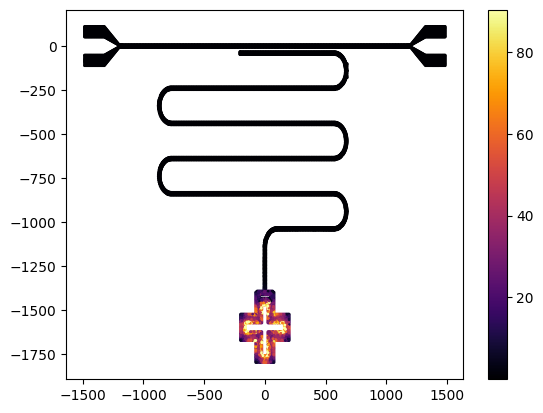

In [20]:
%matplotlib inline
eigenmode_simulation.plot_field(field="E",index=1) # plot magnitude of electric field [V/m]

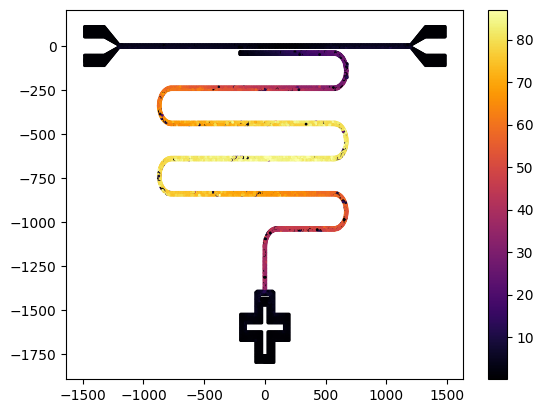

In [21]:
eigenmode_simulation.plot_field(field="E",index=3) # plot magnitude of electric field [V/m]

the above field distributions confirm that the first mode corresponds to our qubit and the third mode corresponds to the resonator. The second mode looks deceivingly like the resonator mode as well but the field shape implies it's a spurious mode. This would probably be removed with the addition of airbridges.

# Extract simulation results 

This eigenmode simulation gives us a plethora of relevant data for superconducting circuits:
* **Resonant frequencies**  $\rightarrow$ intrinsically returned from eigenmode sims.
* **Energy participation of the junction (EPR)** $\rightarrow$ automatically returned if we define a junction lumped port.
* **Resonator's $\kappa_\text{ext}$** $\rightarrow$ automatically returned if we define external feedline ports.

pyPalace has some nice functionality to cleanly extract these simulation results. 

In [22]:
# extract simulation results needed for EPR 
## eigenmode frequencies
fq = eigenmode_simulation.get_frequency_eigenmode(mode=1) # qubit frequency [Hz]
fr = eigenmode_simulation.get_frequency_eigenmode(mode=3) # resonator frequency [Hz]

## participation ratios
pq = eigenmode_simulation.get_portEPR(port_index=1,mode=1) # qubit frequency [Hz]
pr = eigenmode_simulation.get_portEPR(port_index=1,mode=3) # resonator frequency [Hz]

## normalize the ratios 
# not always necessary with Palace from my experience but my Mac Silicon Palace install returns unscaled values
pq = pq/(pq+pr)
pr = pr/(pq+pr)

## resonator kappa_ext, photon decay rate of resonator to feedline
kappa_ext = eigenmode_simulation.get_kappa_ext(mode=3,ports=[2,3])

# EPR Analysis

An eigenmode simulation of a transmon-resonator system followed by EPR analysis enables us to extract almost every Hamiltonian parameter of interest. EPR is an especially useful quantum analysis technique since it is geometry agnostic. **But** Eigenmode simulations are the most computationally expensive simulation type, especially as one moves to larger devices.

## Brief look at EPR

Below is a brief look at EPR analysis. Quantum mechanically the participation $p_m$ of the junction in mode $m$ is given by [Minev et al. (2021)](https://doi.org/10.1038/s41534-021-00457-2):

$$
p_m = \frac{\langle\psi_m|\frac{1}{2}E_J\hat{\varphi}^2|\psi_m\rangle}{\langle\psi_m|\frac{1}{2}\hat{H}_\text{lin}|\psi_m\rangle}
$$

where $\hat{H}_\text{lin} = \hbar\omega_r\hat{a}^\dagger\hat{a} + \hbar\omega_q\hat{b}^\dagger\hat{b}$. Palace extracts the participations classically (see [here](https://awslabs.github.io/palace/stable/reference/#Energy-participation-ratios)).

$$
p_{mj} = \frac{L_j I_{mj}^2}{2\mathcal{E}_m^\text{elec}}
$$

where $p_{mj}$ is the participation of junction $j$ in mode $m$, $I_{mj}$ is the is the peak current of junction $j$ for mode $m$,   $\mathcal{E}_m^\text{elec}$ is the electric energy stored in mode $m$.


## Using participations for quantum analysis

After extracting participations of the qubit and the resonator, we can use the following analytic equations to compute Hamiltonian parameters [Minev et al. (2021)](https://doi.org/10.1038/s41534-021-00457-2): 

qubit anharmonicity: $$\alpha = p_q^2\frac{\hbar\omega_q^2}{8E_J}$$

qubit–resonator dispersive shift: $$\chi = p_qp_r\frac{\hbar\omega_q\omega_r}{4E_J}$$

We can use the dispersive shift to calculate the qubit-resonator coupling strength [non-RWA] [Shanto et al. (2024)](https://doi.org/10.22331/q-2024-09-09-1465):


$$
g=\sqrt{\frac{\chi}{2\left(\frac{\alpha_q}{\Delta(\Delta-\alpha_q)}+\frac{\alpha_q}{\Sigma(\Sigma+\alpha_q)}\right)}}
$$


> For a more in-depth look at quantum analysis techniques, check out the **EM Quantum Analysis Techniques** workshop led by Alp Sipahigil (if you are attending QDW).


In [23]:
from pypalace.analysis import EPR

In [24]:
alpha = EPR.calculate_anharmonicity(pq, fq, LJ)
chi = EPR.calculate_dispersive_shift(pq, pr, fq, fr, LJ)
g = EPR.calculate_coupling_strength(fq, fr, alpha, chi)

We now have all the desired Hamiltonian parameters for a single transmon-resonator system:

In [25]:
print("Hamiltonian parameters:")
print("=======================")
print("\nQubit parameters:")
print("-----------------------")
print(f"f_q = {fq/1e9:.2f} GHz")
print(f"alpha = {alpha/1e6:.2f} MHz")
print("\nResonator parameters:")
print("-----------------------")
print(f"f_r = {fr/1e9:.2f} GHz")
print(f"kappa_ext = {kappa_ext/1e6:.2f} MHz (way too large -- looking into causes)")
print("\nCoupled parameters:")
print("-----------------------")
print(f"chi = {chi/1e6:.2f} MHz")
print(f"g = {g/1e6:.2f} MHz")

print("\nMesh resolution and simulation parameters were very coarse - these values have large uncertainties")

Hamiltonian parameters:

Qubit parameters:
-----------------------
f_q = 5.37 GHz
alpha = -200.10 MHz

Resonator parameters:
-----------------------
f_r = 6.79 GHz
kappa_ext = 14.23 MHz (way too large -- looking into causes)

Coupled parameters:
-----------------------
chi = -1.05 MHz
g = 77.58 MHz

Mesh resolution and simulation parameters were very coarse - these values have large uncertainties


# Next tutorial: electrostatic simulation + LOM

Continue with [`electrostatic_LOM.ipynb`](./electrostatic_LOM.ipynb) — electrostatic simulation of a grounded transmon with capacitance extraction and LOM analysis.
